# Grover's Search Algorithm

### 1. Problem Statement
Imagine an unsorted database containing $N = 2^n$ items. You need to find one specific "marked" item, denoted as $\omega$. Because the database has no underlying structure or sorting, you cannot use classical shortcuts like binary search.

The objective is to locate the marked item $|\omega\rangle$ using the minimum number of queries to a black-box Oracle that recognizes it.

### 2. Quantum Advantage: $O(N)$ vs $O(\sqrt{N})$
* **Classical Complexity:** A classical computer must check items one by one. In the worst case, it must check all $N$ items, and on average, it will check $N/2$ items. This results in $O(N)$ complexity.
* **Quantum Complexity:** Grover's algorithm evaluates all possibilities in superposition and uses interference to amplify the probability of the correct answer. It finds the marked item with high probability in exactly $O(\sqrt{N})$ queries. This quadratic speedup is massive for cryptanalysis and optimization problems where the search space grows exponentially.

### 3. Core Quantum Mechanics: Amplitude Amplification



Grover's algorithm does not "search" in the classical sense. Instead, it relies on a geometric rotation in the Hilbert space known as **Amplitude Amplification**, which consists of two repeating steps:

**1. The Oracle (Phase Inversion):**
The Oracle identifies the marked state $|\omega\rangle$ and applies a negative phase shift to it, effectively flipping its amplitude across the x-axis. All other unmarked states are left entirely unchanged.
$$U_\omega |x\rangle = \begin{cases} -|x\rangle & \text{if } x = \omega \\ |x\rangle & \text{if } x \neq \omega \end{cases}$$

**2. The Diffuser (Inversion About the Mean):**
Flipping the phase of the marked state lowers the *average* amplitude of the entire system. The Diffuser circuit then mirrors all amplitudes around this new, slightly lower average. Because the marked state's amplitude was negative, mirroring it pushes it significantly higher in the positive direction, while slightly shrinking the amplitudes of all the incorrect states.

### 4. Step-by-Step Mathematical Evolution

**Step 1: State Initialization**
Initialize an $n$-qubit register to $|0\rangle^{\otimes n}$.
$$|\psi_0\rangle = |0\rangle^{\otimes n}$$

**Step 2: Uniform Superposition**
Apply Hadamard ($H$) gates to all qubits to create an equal superposition of all $N$ possible states, representing the entire search space. Let's call this uniform state $|s\rangle$.
$$|\psi_1\rangle = |s\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$$

**Step 3: The Grover Iteration**
Repeat the following two operations approximately $\frac{\pi}{4}\sqrt{N}$ times:
* **Apply the Oracle ($U_\omega$):** Flips the phase of $|\omega\rangle$.
* **Apply the Diffuser ($U_s$):** Inverts amplitudes about the mean. Mathematically, the diffuser is defined as $U_s = 2|s\rangle\langle s| - I$.

With each iteration, the probability amplitude of $|\omega\rangle$ grows closer to 1. 

**Step 4: Measurement**
After the optimal number of iterations, the quantum state aligns almost entirely with the target state. Measuring the register will yield the classical bitstring $\omega$ with a probability approaching $100\%$.


### PART 1. Grover's search for 2-Qubits

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [7]:
def build_2qubit_grover()-> QuantumCircuit:
    qc = QuantumCircuit(2)

    qc.h([0,1])
    qc.barrier()

    qc.cz(0,1)
    qc.barrier()

    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1) # Multi-controlled Z variant for phase shift
    qc.x([0, 1])
    qc.h([0, 1])
    qc.barrier()


    qc.measure_all()
    
    return qc
    

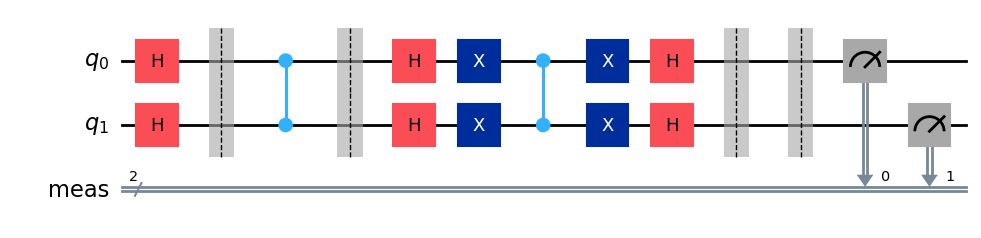

In [9]:
grover_circuit = build_2qubit_grover()
grover_circuit.draw('mpl')

In [10]:
sim = AerSimulator()
job = sim.run(grover_circuit, shots = 100)
result = job.result()
counts = result.get_counts()
print("Grover's Search Circuit Output (Target: 11):")
print(counts)

Grover's Search Circuit Output (Target: 11):
{'11': 100}


### Part 2. Generalizing for $n$-Qubits

To build a universally scalable Grover search, three components of the algorithm must become dynamic:

**1. Iteration Calculation ($R$)**
In the 2-qubit system, we achieved a $100\%$ success rate with exactly 1 iteration. As the qubit count $n$ grows, the total search space becomes $N = 2^n$. To prevent over-rotation and maximize the probability amplitude of the target state, the number of Grover iterations must be dynamically calculated as:
$$R = \lfloor \frac{\pi}{4}\sqrt{N} \rfloor$$

**2. The Generalized Phase Oracle**
A generalized Oracle must be able to target any arbitrary binary string (e.g., `10110`). We achieve this by:
* Applying Pauli-$X$ gates to all qubits where the target string has a `0`. This temporarily flips them to `1`.
* Applying a Multi-Controlled Z gate ($MCZ$) across all $n$ qubits. This applies the crucial $(-1)$ phase shift only when all qubits are `1`.
* Applying Pauli-$X$ gates again to the exact same qubits to uncompute the initial flips, returning the state to its original configuration but with the negated phase securely kicked back.

**3. The Generalized Diffuser**
The Diffuser performs the "inversion about the mean." For an $n$-qubit circuit, the geometric reflection is executed by:
* Applying $H$ gates to all $n$ qubits.
* Applying $X$ gates to all $n$ qubits.
* Applying an $n$-qubit Multi-Controlled Z gate ($MCZ$).
* Uncomputing with $X$ gates to all $n$ qubits.
* Uncomputing with $H$ gates to all $n$ qubits.

In [12]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [15]:
def bulid_nQubits_grover(target_state: str)-> QuantumCircuit:
    n = len(target_state)
    N = 2**n

    # 1. Calculate optimal number of Grover iterations to prevent over-rotation
    iterations = int(np.floor((np.pi / 4) * np.sqrt(N)))
    print(f"System Architecture: {n} Qubits | Search Space: {N} States")
    print(f"Optimal Grover Iterations Computed: {iterations}\n")

    qc = QuantumCircuit(n)

    qc.h(range(n))
    qc.barrier()

    for _ in range(iterations):

        reversed_target = target_state[::-1]

        for i in range(n):
            if reversed_target[i] == '0':
                qc.x(i)
        
        qc.h(n-1)
        if n>1:
            qc.mcx(list(range(n-1)),n-1)
        qc.h(n-1)

        for i in range(n):
            if reversed_target[i] == '0':
                qc.x(i)

        qc.barrier(label="Oracle")

        qc.h(range(n))
        qc.x(range(n))

        qc.h(n-1)
        if n > 1:
            qc.mcx(list(range(n - 1)), n - 1)
        qc.h(n - 1)
        
        qc.x(range(n))
        qc.h(range(n))
        
        qc.barrier(label="Diffuser")

        qc.measure_all()

        return qc
        

System Architecture: 4 Qubits | Search Space: 16 States
Optimal Grover Iterations Computed: 3



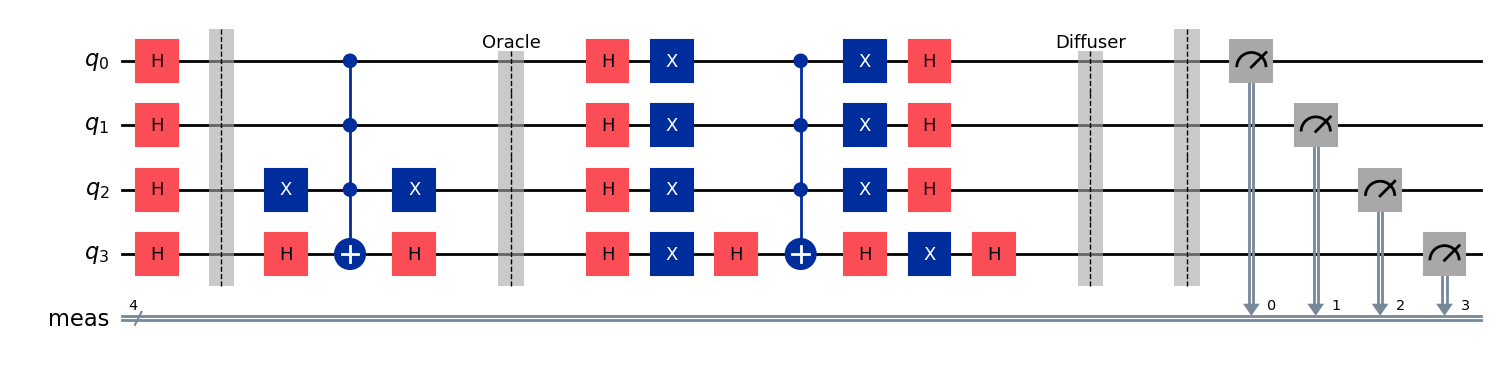

In [18]:
secret_target = '1011'
n_grover_circuit = bulid_nQubits_grover(secret_target)
n_grover_circuit.draw('mpl')

Target Search State: 1011
Measurement Output:  {'1011': 459, '1110': 44, '0101': 37, '0111': 33, '0000': 40, '0100': 31, '1111': 33, '0110': 38, '1100': 36, '1010': 36, '1001': 37, '0011': 34, '1101': 44, '0001': 25, '0010': 34, '1000': 39}


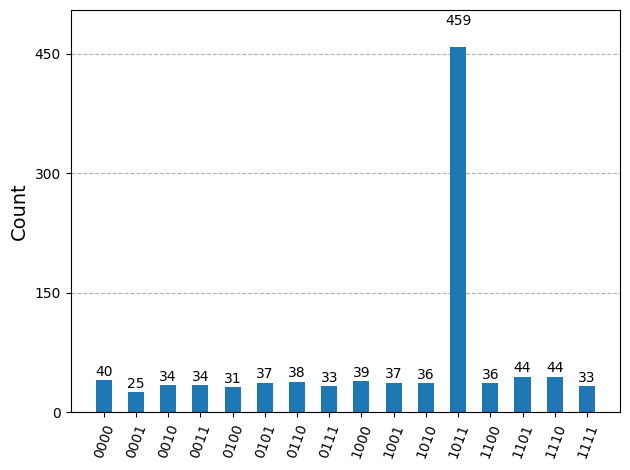

In [32]:
sim = AerSimulator()
job = sim.run(n_grover_circuit, shots = 1000)
result = job.result()
counts = result.get_counts()
print(f"Target Search State: {secret_target}")
print(f"Measurement Output:  {counts}")
plot_histogram(counts)

# The Reality of Grover's: Boolean Function Inversion

### 1. The "Unsorted Database" Myth
Grover's algorithm is traditionally introduced using the analogy of finding a specific item in an unsorted database. However, this pedagogical simplification breaks down mathematically. The computational basis states of a quantum register ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$) are inherently perfectly ordered. If the objective is simply to find the binary string `1011`, a classical algorithm requires zero queries—it simply writes the string. 

Therefore, Grover's algorithm is not a "search" algorithm in the classical sense. It is formally an **Amplitude Amplification protocol for Boolean Function Inversion**. 

### 2. The True Objective: Evaluating Conditions
Instead of searching for a known string, Grover's algorithm is used to find an unknown input $x$ that satisfies a complex mathematical condition, represented as a black-box function $f(x)$. 
The objective is to find $x$ such that $f(x)=1$, where the relationship between the input $x$ and the output of $f(x)$ is highly non-linear, unpredictable, or computationally expensive to calculate classically.

### 3. Application: Multi-Objective Route Optimization
Consider the challenge of finding the optimal path in a routing network. 

* **The Input Space (Sorted):** We can systematically generate and order all possible route combinations in an $n$-qubit register (Route 0, Route 1, Route 2... Route $N$).
* **The Solution Landscape (Unsorted):** We do not know *which* of these routes yields a total distance or cost below a specific threshold (e.g., $\text{Cost}(x) < 500$). The output values are entirely unstructured relative to the input IDs.

To solve this classically, one must evaluate the cost function for every route. For exponentially large networks, this becomes intractable, forcing reliance on classical heuristic approximations like Augmented Particle Swarm Optimization (APSO) to find "good enough" local minima. 

Grover's algorithm provides a quadratic speedup for finding the exact, global optimal solution. It evaluates the cost function for all routes simultaneously in superposition.

### 4. The Anatomy of a Practical Oracle
In a real-world quantum implementation, the Phase Oracle is not a simple string-matching circuit. It is a massive quantum sub-routine that performs arithmetic.

A functional Routing Oracle operates as follows:
1.  **Compute:** It takes the superposition of all routes $|x\rangle$ and computes their respective costs into an auxiliary register: $|x\rangle |Cost(x)\rangle$.
2.  **Evaluate:** It applies a quantum comparator circuit. If the value in the cost register is less than the target threshold, it flips a flag qubit.
3.  **Phase Kickback:** A Multi-Controlled Z gate targets this flag qubit, kicking back a $(-1)$ phase *only* to the route states $|x\rangle$ that satisfy the condition.
4.  **Uncompute:** It reverses the arithmetic to unentangle the auxiliary register, leaving the system in the state $(-1)^{f(x)}|x\rangle$.

The Diffuser then geometrically amplifies the probability of measuring these valid routes. The user discovers the optimal route upon measurement, having never known the answer beforehand.